In [1]:
import pandas as pd
df = pd.read_csv("earthquakes.csv")
df

,id,impact.gap,impact.magnitude,impact.significance,location.depth,location.distance,location.full,location.latitude,location.longitude,location.name,time.day,time.epoch,time.full,time.hour,time.minute,time.month,time.second,time.year
0,nc72666881,122.00,1.43,31,15.12,0.10340,"13km E of Livermore, California",37.672333,-121.619000,California,27,1469593183550,2016-07-27 00:19:43,0,19,7,43,2016
1,us20006i0y,30.00,4.90,371,97.07,1.43900,"58km WNW of Pakokku, Burma",21.514600,94.572100,Burma,27,1469593228220,2016-07-27 00:20:28,0,20,7,28,2016
2,nc72666891,249.00,0.06,0,4.39,0.02743,"12km SE of Mammoth Lakes, California",37.576500,-118.859167,California,27,1469593897150,2016-07-27 00:31:37,0,31,7,37,2016
3,nc72666896,122.00,0.40,2,1.09,0.02699,"6km SSW of Mammoth Lakes, California",37.595833,-118.994833,California,27,1469594144150,2016-07-27 00:35:44,0,35,7,44,2016
4,nn00553447,113.61,0.30,1,7.60,0.06300,"16km SSE of Mogul, Nevada",39.377500,-119.845000,Nevada,27,1469594519667,2016-07-27 00:41:59,0,41,7,59,2016
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8389,nc72685246,47.00,2.42,90,4.85,0.06167,"22km ENE of Soledad, California",36.515499,-121.099831,California,25,1472181541970,2016-08-25 23:19:01,23,19,8,1,2016
8390,ak13879193,0.00,1.40,30,50.00,0.00000,"5km ESE of Big Lake, Alaska",61.498400,-149.862700,Alaska,25,1472181558000,2016-08-25 23:19:18,23,19,8,18,2016
8391,nc72685251,165.00,1.06,17,1.73,0.02042,"6km WNW of The Geysers, California",38.805000,-122.821503,California,25,1472182205600,2016-08-25 23:30:05,23,30,8,5,2016
8392,ci37672328,103.00,1.55,37,29.25,0.06980,"6km NNW of Chatsworth, CA",34.308000,-118.635333,California,25,1472182571880,2016-08-25 23:36:11,23,36,8,11,2016


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
from torch.utils.data import TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [3]:
torch.manual_seed(0) # Seed for reproducibility

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # Uses GPU if available, cpu otherwise

In [5]:
df_sorted = df.sort_values('time.epoch') # Sort the data based on epoch so the time points will be in the right order
y = df_sorted['impact.magnitude'].values.astype(np.float32) # Dependent variable
# Drop variables that are not used
X = df_sorted.drop(['impact.magnitude','id','location.full','location.name','time.full','time.epoch'],axis=1).values.astype(np.float32)
feature_names=df.drop(['impact.magnitude','id','location.full','location.name','time.full','time.epoch'],axis=1).columns
# Create train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, shuffle=False
)

In [6]:
# Scale the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
X_train_data = []
y_train_data = []
X_test_data = []
y_test_data = []
# Sliding window method
for i in range(len(X_train_scaled)-20):
    X_train_data.append(X_train_scaled[i:i+20])
    y_train_data.append(y_train[i+20])
for i in range(len(X_test_scaled)-20):
    X_test_data.append(X_test_scaled[i:i+20])
    y_test_data.append(y_test[i+20])

# Turn data into tensors
X_train_tensor = torch.tensor(X_train_data, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_data, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test_data, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_data, dtype=torch.float32).unsqueeze(1)

train_data = TensorDataset(X_train_tensor, y_train_tensor)
test_data = TensorDataset(X_test_tensor, y_test_tensor)

C:\Users\sarah\AppData\Local\Temp\ipykernel_25652\3137161417.py:14: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  X_train_tensor = torch.tensor(X_train_data, dtype=torch.float32)


In [8]:
# Put the tensors in dataloaders
train_loader = data.DataLoader(train_data, batch_size=64, shuffle=False, num_workers=2)
test_loader = data.DataLoader(test_data, batch_size=64, shuffle=False, num_workers=2)

In [9]:
# Define the MLP
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        # Four linear layers
        self.fc1 = nn.Linear(X_train_tensor.shape[1]*X_train_tensor.shape[2], 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128,64)
        self.fc4 = nn.Linear(64, 1)

    def forward(self, x):
        # Each layer has a ReLU activation function
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        return x

In [10]:
model = MLP().to(device)
criterion = nn.MSELoss() # We use MSE as the loss function
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

In [11]:
# Train for 30 epochs
for epoch in range(30):
    model.train()
    running_loss = 0.0

    for variables, labels in train_loader:
        variables = variables.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(variables)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print('Epoch {} training loss: {:.3f}'.format(epoch+1, running_loss/len(train_loader)))

Epoch 1 training loss: 1.551
Epoch 2 training loss: 1.270
Epoch 3 training loss: 1.251
Epoch 4 training loss: 1.240
Epoch 5 training loss: 1.231
Epoch 6 training loss: 1.223
Epoch 7 training loss: 1.214
Epoch 8 training loss: 1.204
Epoch 9 training loss: 1.194
Epoch 10 training loss: 1.182
Epoch 11 training loss: 1.170
Epoch 12 training loss: 1.156
Epoch 13 training loss: 1.140
Epoch 14 training loss: 1.123
Epoch 15 training loss: 1.103
Epoch 16 training loss: 1.081
Epoch 17 training loss: 1.056
Epoch 18 training loss: 1.029
Epoch 19 training loss: 1.001
Epoch 20 training loss: 0.971
Epoch 21 training loss: 0.951
Epoch 22 training loss: 0.918
Epoch 23 training loss: 0.890
Epoch 24 training loss: 0.905
Epoch 25 training loss: 0.853
Epoch 26 training loss: 0.810
Epoch 27 training loss: 0.744
Epoch 28 training loss: 0.735
Epoch 29 training loss: 0.861
Epoch 30 training loss: 0.632


In [12]:
# Evaluate the model on the test set
model.eval()
total_mse = 0.0
count = 0

with torch.no_grad():
    for variables, labels in test_loader:
        variables = variables.to(device)
        labels = labels.to(device)
        outputs = model(variables)
        mse = criterion(outputs, labels).item()
        total_mse += mse
        count += 1

# Calculate MSE
average_mse = total_mse / count

print('MSE on test data:',average_mse)

MSE on test data: 2.41367898985397


In [13]:
from captum.attr import LRP
from captum.attr import Saliency

In [14]:
# Import explanation methods
saliency = Saliency(model)
lrp = LRP(model)

In [15]:
# Averages the explanations of all datapoint in the test set
attribute = []
gradients = []
for sample in X_test_tensor:
  sample = sample.reshape(1,-1).to(device)
  attribute.append(lrp.attribute(sample).reshape(1,20,-1).squeeze().cpu().detach().numpy()) #LRP
  gradients.append(saliency.attribute(sample,abs=False).reshape(1,20,-1).squeeze().cpu().detach().numpy()) #Vanilla Gradients
average_attr = np.mean(attribute,axis=0)
average_grad = np.mean(gradients,axis=0)

C:\Users\sarah\Python\Lib\site-packages\captum\attr\_core\lrp.py:207: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(input_tuple)
C:\Users\sarah\Python\Lib\site-packages\captum\attr\_core\saliency.py:129: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(inputs_tuple)


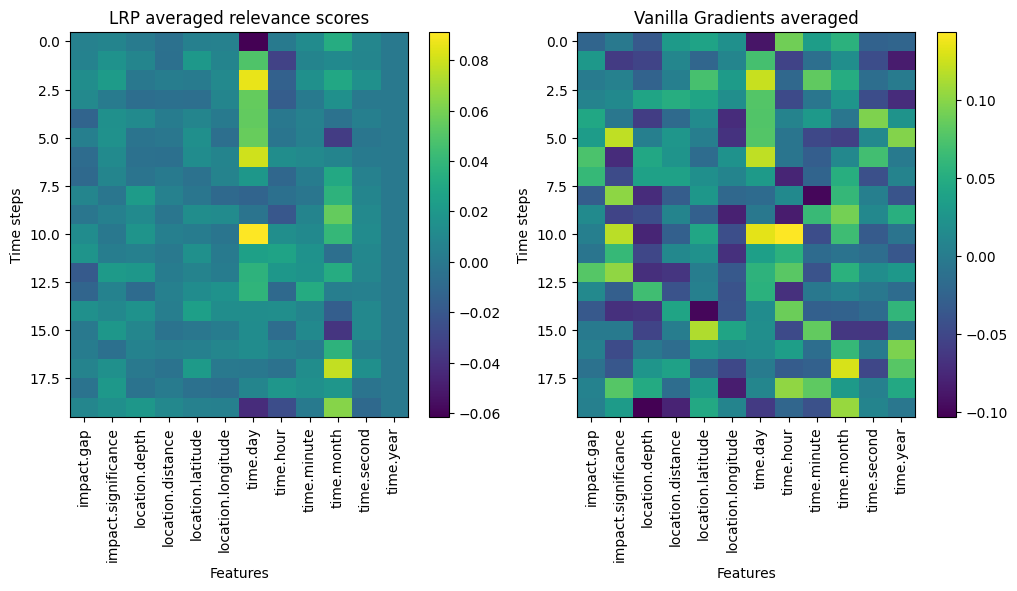

In [16]:
# Plotting the averaged explanations in heat maps
fig,ax = plt.subplots(1,2,figsize=(12,5))

#LRP
plot1 = ax[0].imshow(average_attr,aspect='auto')
plt.colorbar(plot1,ax=ax[0])
ax[0].set_title("LRP averaged relevance scores")
ax[0].set_xticks(range(len(feature_names)),labels=feature_names,rotation=90)
ax[0].set_xlabel("Features")
ax[0].set_ylabel("Time steps")

#Vanilla Gradients
plot2 = ax[1].imshow(average_grad,aspect='auto')
plt.colorbar(plot2,ax=ax[1])
ax[1].set_title("Vanilla Gradients averaged")
ax[1].set_xticks(range(len(feature_names)),labels=feature_names,rotation=90)
ax[1].set_xlabel("Features")
ax[1].set_ylabel("Time steps")
plt.show()

C:\Users\sarah\Python\Lib\site-packages\captum\attr\_core\lrp.py:207: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(input_tuple)
C:\Users\sarah\Python\Lib\site-packages\captum\attr\_core\saliency.py:129: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(inputs_tuple)


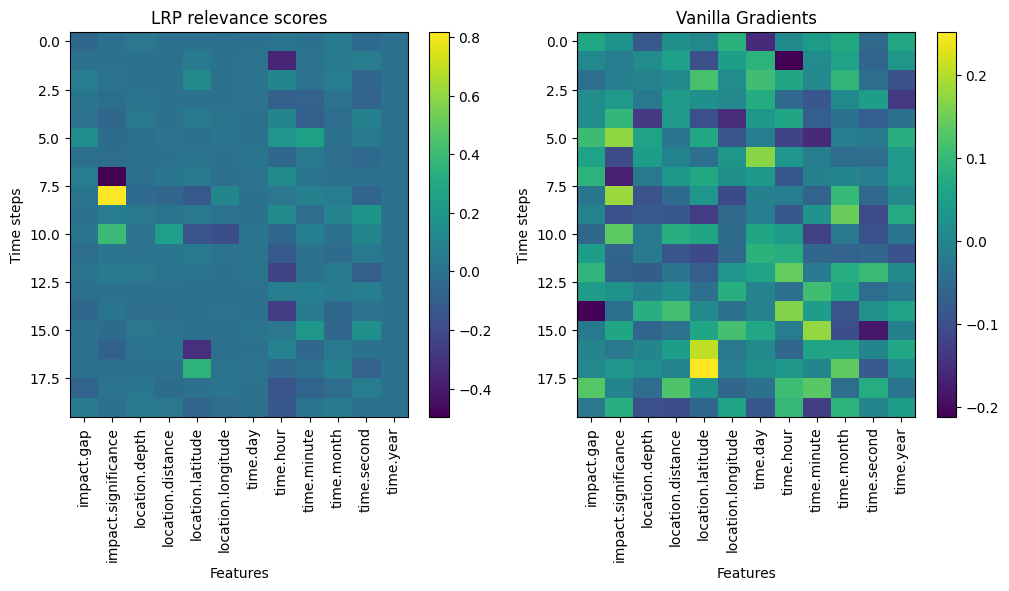

In [17]:
# Calculating and plotting the explanations of datapoint 20 of the test set
sample = X_test_tensor[20].reshape(1,-1).to(device)
attribute = lrp.attribute(sample).reshape(1,20,-1).squeeze().cpu().detach().numpy() # LRP
gradients = saliency.attribute(sample,abs=False).reshape(1,20,-1).squeeze().cpu().detach().numpy() # Vanilla Gradients

# LRP
fig,ax = plt.subplots(1,2,figsize=(12,5))
plot1 = ax[0].imshow(attribute,aspect='auto')
plt.colorbar(plot1,ax=ax[0])
ax[0].set_title("LRP relevance scores")
ax[0].set_xticks(range(len(feature_names)),labels=feature_names,rotation=90)
ax[0].set_xlabel("Features")
ax[0].set_ylabel("Time steps")

# Vanilla Gradients
plot2 = ax[1].imshow(gradients,aspect='auto')
plt.colorbar(plot2,ax=ax[1])
ax[1].set_title("Vanilla Gradients")
ax[1].set_xticks(range(len(feature_names)),labels=feature_names,rotation=90)
ax[1].set_xlabel("Features")
ax[1].set_ylabel("Time steps")
plt.show()

C:\Users\sarah\Python\Lib\site-packages\captum\attr\_core\lrp.py:207: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(input_tuple)
C:\Users\sarah\Python\Lib\site-packages\captum\attr\_core\saliency.py:129: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(inputs_tuple)


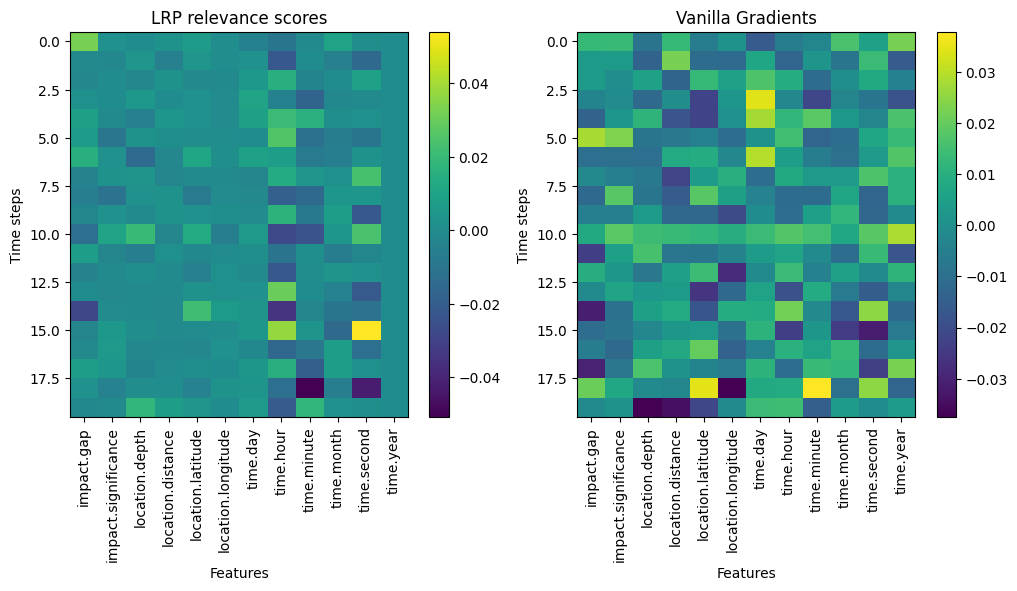

In [18]:
# Calculating and plotting the explanations of datapoint 692 of the test set
sample = X_test_tensor[692].reshape(1,-1).to(device)
attribute = lrp.attribute(sample).reshape(1,20,-1).squeeze().cpu().detach().numpy() # LRP
gradients = saliency.attribute(sample,abs=False).reshape(1,20,-1).squeeze().cpu().detach().numpy() # Vanilla Gradients

#LRP
fig,ax = plt.subplots(1,2,figsize=(12,5))
plot1 = ax[0].imshow(attribute,aspect='auto')
plt.colorbar(plot1,ax=ax[0])
ax[0].set_title("LRP relevance scores")
ax[0].set_xticks(range(len(feature_names)),labels=feature_names,rotation=90)
ax[0].set_xlabel("Features")
ax[0].set_ylabel("Time steps")

#Vanilla Gradients
plot2 = ax[1].imshow(gradients,aspect='auto')
plt.colorbar(plot2,ax=ax[1])
ax[1].set_title("Vanilla Gradients")
ax[1].set_xticks(range(len(feature_names)),labels=feature_names,rotation=90)
ax[1].set_xlabel("Features")
ax[1].set_ylabel("Time steps")
plt.show()

C:\Users\sarah\Python\Lib\site-packages\captum\attr\_core\lrp.py:207: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(input_tuple)
C:\Users\sarah\Python\Lib\site-packages\captum\attr\_core\saliency.py:129: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(inputs_tuple)


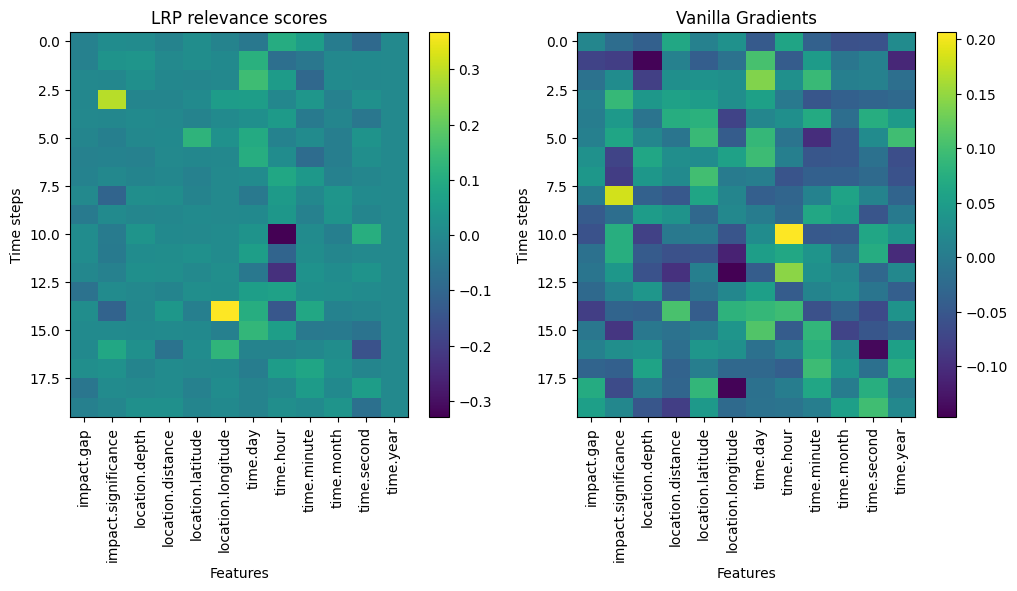

In [19]:
# Calculating and plotting the explanations of datapoint 2526 of the test set
sample = X_test_tensor[2526].reshape(1,-1).to(device)
attribute = lrp.attribute(sample).reshape(1,20,-1).squeeze().cpu().detach().numpy() # LRP
gradients = saliency.attribute(sample,abs=False).reshape(1,20,-1).squeeze().cpu().detach().numpy() # Vanilla Gradients

# LRP
fig,ax = plt.subplots(1,2,figsize=(12,5))
plot1 = ax[0].imshow(attribute,aspect='auto')
plt.colorbar(plot1,ax=ax[0])
ax[0].set_title("LRP relevance scores")
ax[0].set_xticks(range(len(feature_names)),labels=feature_names,rotation=90)
ax[0].set_xlabel("Features")
ax[0].set_ylabel("Time steps")

# Vanilla Gradients
plot2 = ax[1].imshow(gradients,aspect='auto')
plt.colorbar(plot2,ax=ax[1])
ax[1].set_title("Vanilla Gradients")
ax[1].set_xticks(range(len(feature_names)),labels=feature_names,rotation=90)
ax[1].set_xlabel("Features")
ax[1].set_ylabel("Time steps")
plt.show()